# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

## Prepare DataSet

### *Download* DataSet

In [1]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2025-10-05 05:21:45--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.167.192.111, 3.167.192.32, 3.167.192.56, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.167.192.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   370MB/s    in 0.9s    

2025-10-05 05:21:46 (370 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  sample_data


# VGG16 Transfer Learning

VGG16 TRANSFER LEARNING - BEST PRACTICES IMPLEMENTATION
TensorFlow Version: 2.19.0
GPU Available: True
✓ Created output directories in vgg16_results

🚀 STARTING VGG16 EXPERIMENTS

DATA PREPARATION WITH 60/20/20 SPLIT
Found 13779 parasitized images
Found 13779 uninfected images
Total: 27558 images
TRAIN set: 16534 images (8267 P, 8267 U)
VAL   set:  5512 images (2756 P, 2756 U)
TEST  set:  5512 images (2756 P, 2756 U)

📊 PHASE 1: BASELINE EXPERIMENT

EXPERIMENT 1: BASELINE VGG16 (FROZEN FEATURES)

=== Creating Data Generators ===
✓ Training without augmentation
Found 16534 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.

=== Building VGG16 Model ===
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ Loaded VGG16 with 19 layers

Model Summary:
Total parameters: 14,880,577
Trainable parameters: 165,121
Non-trainable parameters: 14,715,456

📊 Training Baseline Model...
----------------------------------------
Epoch 1/20
5

517/517 ━━━━━━━━━━━━━━━━━━━━ 150s 257ms/step - accuracy: 0.8850 - loss: 0.2868 - precision: 0.8676 - recall: 0.9043 - val_accuracy: 0.9438 - val_loss: 0.1532 - val_precision: 0.9349 - val_recall: 0.9539 - learning_rate: 0.0010
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9380 - loss: 0.1694 - precision: 0.9339 - recall: 0.9427
Epoch 2: val_accuracy improved from 0.94376 to 0.94467, saving model to vgg16_results/checkpoints/exp1_baseline_frozen_best.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.9380 - loss: 0.1694 - precision: 0.9339 - recall: 0.9427 - val_accuracy: 0.9447 - val_loss: 0.1522 - val_precision: 0.9432 - val_recall: 0.9463 - learning_rate: 0.0010
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9476 - loss: 0.1551 - precision: 0.9442 - recall: 0.9512
Epoch 3: val_accuracy did not improve from 0.94467
517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.9476 - loss: 0.1551 - precision: 0.9442 - recall: 0.9512 - val_accuracy: 0.9405 - val_loss: 0.1632 - val_precision: 0.9126 - val_recall: 0.9742 - learning_rate: 0.0010
Epoch 4/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9431 - loss: 0.1591 - precision: 0.9383 - recall: 0.9483
Epoch 4: val_accuracy improved from 0.94467 to 0.94902, saving model to vgg16_results/checkpoints/exp1_baseline_frozen_best.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.9431 - loss: 0.1591 - precision: 0.9383 - recall: 0.9483 - val_accuracy: 0.9490 - val_loss: 0.1452 - val_precision: 0.9463 - val_recall: 0.9521 - learning_rate: 0.0010
Epoch 5/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9444 - loss: 0.1544 - precision: 0.9384 - recall: 0.9510
Epoch 5: val_accuracy did not improve from 0.94902
517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 226ms/step - accuracy: 0.9444 - loss: 0.1544 - precision: 0.9384 - recall: 0.9510 - val_accuracy: 0.9461 - val_loss: 0.1483 - val_precision: 0.9589 - val_recall: 0.9321 - learning_rate: 0.0010
Epoch 6/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9484 - loss: 0.1454 - precision: 0.9457 - recall: 0.9524
Epoch 6: val_accuracy did not improve from 0.94902
517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.9484 - loss: 0.1455 - precision: 0.9457 - recall: 0.9524 - val_accuracy: 0.9483 - val_loss: 0.1448 - val_precision: 0.9443 - val_recall

517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.9475 - loss: 0.1494 - precision: 0.9401 - recall: 0.9560 - val_accuracy: 0.9496 - val_loss: 0.1419 - val_precision: 0.9366 - val_recall: 0.9644 - learning_rate: 0.0010
Epoch 8/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9450 - loss: 0.1485 - precision: 0.9429 - recall: 0.9486
Epoch 8: val_accuracy did not improve from 0.94956
517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.9450 - loss: 0.1485 - precision: 0.9429 - recall: 0.9486 - val_accuracy: 0.9421 - val_loss: 0.1652 - val_precision: 0.9670 - val_recall: 0.9155 - learning_rate: 0.0010
Epoch 9/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9497 - loss: 0.1406 - precision: 0.9448 - recall: 0.9554
Epoch 9: val_accuracy did not improve from 0.94956
517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.9497 - loss: 0.1406 - precision: 0.9447 - recall: 0.9554 - val_accuracy: 0.9463 - val_loss: 0.1393 - val_precision: 0.9271 - val_recall

517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.9473 - loss: 0.1499 - precision: 0.9489 - recall: 0.9467 - val_accuracy: 0.9516 - val_loss: 0.1358 - val_precision: 0.9427 - val_recall: 0.9615 - learning_rate: 0.0010
Epoch 13/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9503 - loss: 0.1413 - precision: 0.9496 - recall: 0.9516
Epoch 13: val_accuracy did not improve from 0.95156
517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.9503 - loss: 0.1413 - precision: 0.9496 - recall: 0.9516 - val_accuracy: 0.9474 - val_loss: 0.1436 - val_precision: 0.9240 - val_recall: 0.9750 - learning_rate: 0.0010
Epoch 14/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9514 - loss: 0.1363 - precision: 0.9480 - recall: 0.9556
Epoch 14: val_accuracy improved from 0.95156 to 0.95229, saving model to vgg16_results/checkpoints/exp1_baseline_frozen_best.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 118s 228ms/step - accuracy: 0.9514 - loss: 0.1363 - precision: 0.9480 - recall: 0.9556 - val_accuracy: 0.9523 - val_loss: 0.1354 - val_precision: 0.9441 - val_recall: 0.9615 - learning_rate: 0.0010
Epoch 15/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9543 - loss: 0.1349 - precision: 0.9488 - recall: 0.9605
Epoch 15: val_accuracy did not improve from 0.95229
517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.9543 - loss: 0.1349 - precision: 0.9488 - recall: 0.9605 - val_accuracy: 0.8930 - val_loss: 0.3580 - val_precision: 0.8286 - val_recall: 0.9909 - learning_rate: 0.0010
Epoch 16/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9490 - loss: 0.1349 - precision: 0.9465 - recall: 0.9506
Epoch 16: val_accuracy did not improve from 0.95229
517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 226ms/step - accuracy: 0.9490 - loss: 0.1349 - precision: 0.9465 - recall: 0.9506 - val_accuracy: 0.9454 - val_loss: 0.1421 - val_precision: 0.9223 - val_re

517/517 ━━━━━━━━━━━━━━━━━━━━ 117s 226ms/step - accuracy: 0.9572 - loss: 0.1186 - precision: 0.9520 - recall: 0.9618 - val_accuracy: 0.9546 - val_loss: 0.1289 - val_precision: 0.9478 - val_recall: 0.9623 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 18.


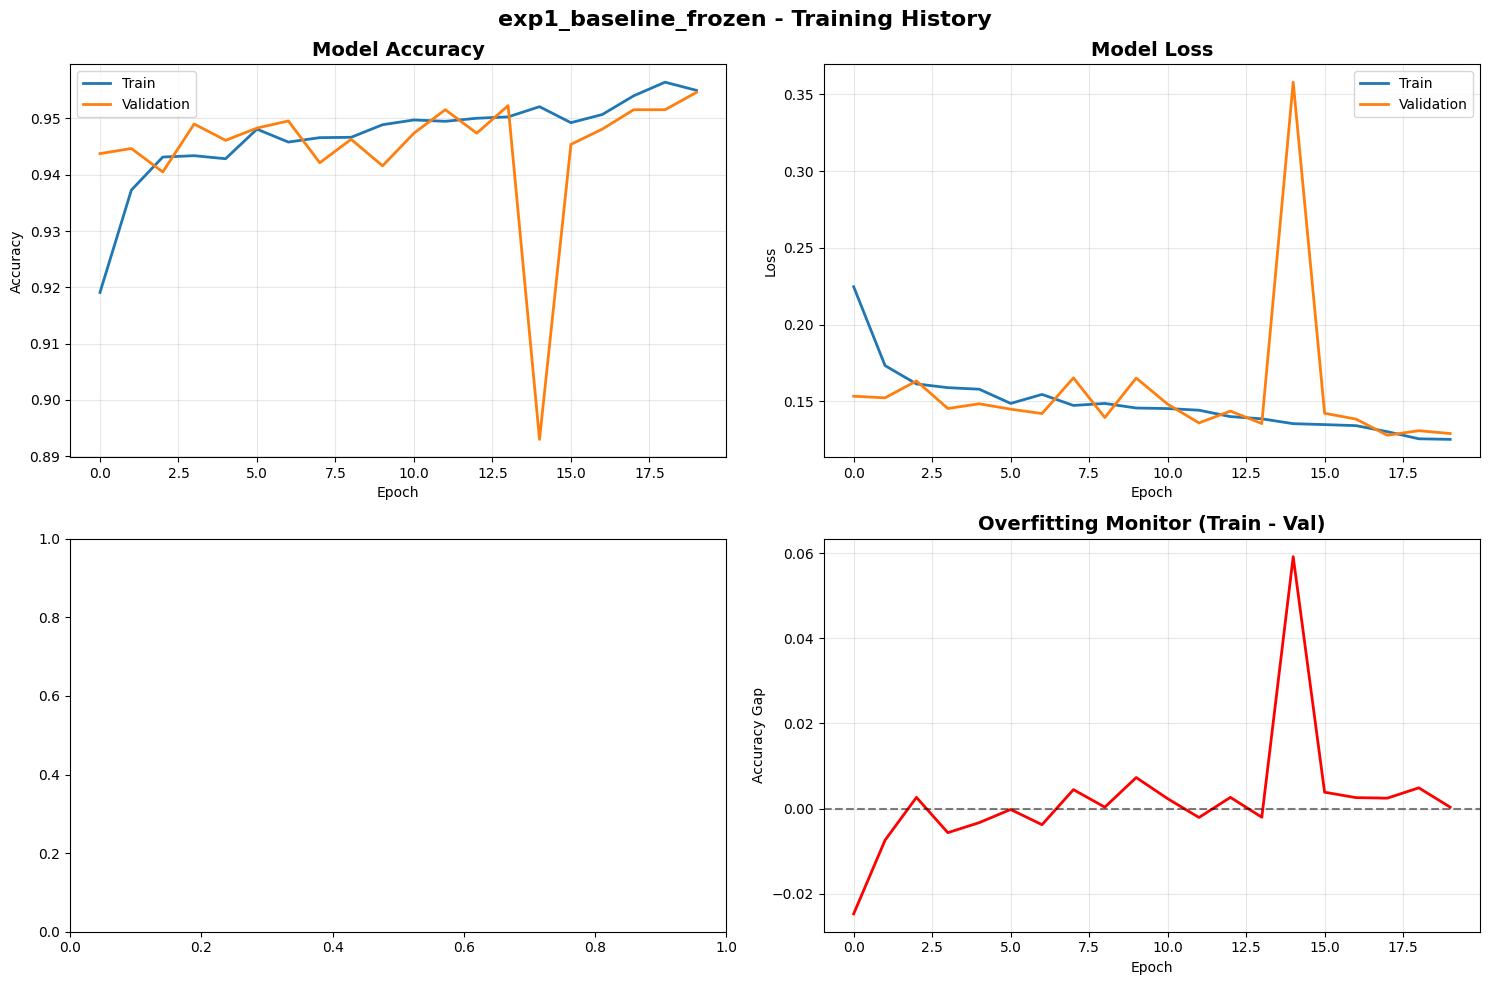

✓ Saved training history plot to vgg16_results/plots/exp1_baseline_frozen_history.png

EVALUATING: exp1_baseline_frozen
173/173 ━━━━━━━━━━━━━━━━━━━━ 31s 174ms/step

📊 Test Set Performance:
   Accuracy:  0.9528 (95.28%)
   Precision: 0.9502
   Recall:    0.9557
   F1-Score:  0.9530
   AUC:       0.9892

📋 Classification Report:
              precision    recall  f1-score   support

  Uninfected     0.9555    0.9499    0.9527      2756
 Parasitized     0.9502    0.9557    0.9530      2756

    accuracy                         0.9528      5512
   macro avg     0.9528    0.9528    0.9528      5512
weighted avg     0.9528    0.9528    0.9528      5512


📊 Confusion Matrix:
   TN: 2618  FP:  138
   FN:  122  TP: 2634


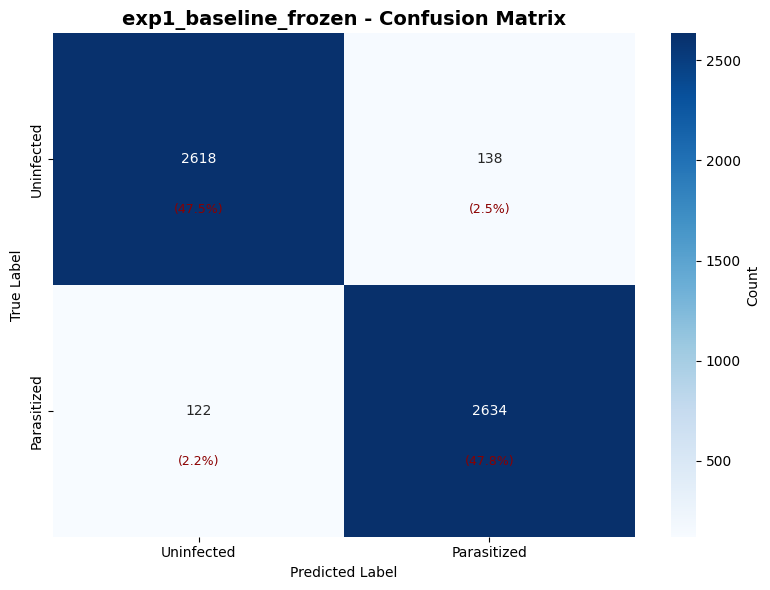

✓ Saved confusion matrix to vgg16_results/plots/exp1_baseline_frozen_confusion.png


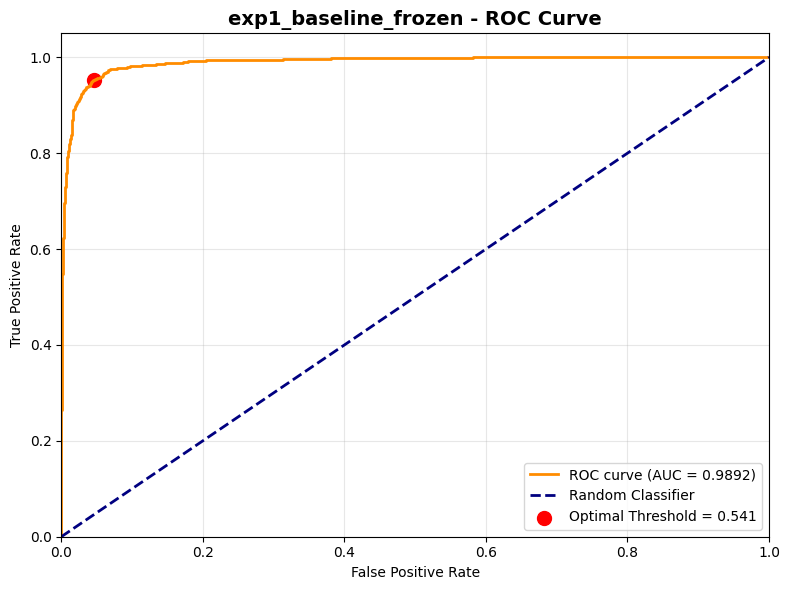

✓ Saved ROC curve to vgg16_results/plots/exp1_baseline_frozen_roc.png
✓ Saved final model to vgg16_results/checkpoints/exp1_baseline_frozen_final.h5

📊 PHASE 2: FINE-TUNING EXPERIMENT

EXPERIMENT 2: FINE-TUNED VGG16 WITH AUGMENTATION

=== Creating Data Generators ===
✓ Training data augmentation enabled
Found 16534 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.

=== Building VGG16 Model ===
✓ Loaded VGG16 with 19 layers
✓ Fine-tuning enabled: 4 VGG16 layers trainable

Model Summary:
Total parameters: 14,880,577
Trainable parameters: 7,244,545
Non-trainable parameters: 7,636,032

📊 Training Fine-tuned Model...
----------------------------------------
Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8584 - loss: 0.3389 - precision: 0.8135 - recall: 0.9242
Epoch 1: val_accuracy improved from -inf to 0.92453, saving model to vgg16_results/checkpoints/exp2_finetuned_augmented_best.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 270s 506ms/step - accuracy: 0.8585 - loss: 0.3388 - precision: 0.8136 - recall: 0.9243 - val_accuracy: 0.9245 - val_loss: 0.2056 - val_precision: 0.8760 - val_recall: 0.9891 - learning_rate: 1.0000e-04
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9266 - loss: 0.2153 - precision: 0.9067 - recall: 0.9517
Epoch 2: val_accuracy did not improve from 0.92453
517/517 ━━━━━━━━━━━━━━━━━━━━ 253s 489ms/step - accuracy: 0.9266 - loss: 0.2153 - precision: 0.9067 - recall: 0.9517 - val_accuracy: 0.5336 - val_loss: 1.0803 - val_precision: 1.0000 - val_recall: 0.0671 - learning_rate: 1.0000e-04
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9326 - loss: 0.1996 - precision: 0.9163 - recall: 0.9505
Epoch 3: val_accuracy improved from 0.92453 to 0.95337, saving model to vgg16_results/checkpoints/exp2_finetuned_augmented_best.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 265s 494ms/step - accuracy: 0.9326 - loss: 0.1996 - precision: 0.9163 - recall: 0.9505 - val_accuracy: 0.9534 - val_loss: 0.1328 - val_precision: 0.9295 - val_recall: 0.9811 - learning_rate: 1.0000e-04
Epoch 4/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9362 - loss: 0.1814 - precision: 0.9225 - recall: 0.9528
Epoch 4: val_accuracy improved from 0.95337 to 0.95773, saving model to vgg16_results/checkpoints/exp2_finetuned_augmented_best.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 254s 492ms/step - accuracy: 0.9362 - loss: 0.1814 - precision: 0.9225 - recall: 0.9528 - val_accuracy: 0.9577 - val_loss: 0.1178 - val_precision: 0.9543 - val_recall: 0.9615 - learning_rate: 1.0000e-04
Epoch 5/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9389 - loss: 0.1755 - precision: 0.9294 - recall: 0.9505
Epoch 5: val_accuracy did not improve from 0.95773
517/517 ━━━━━━━━━━━━━━━━━━━━ 255s 492ms/step - accuracy: 0.9389 - loss: 0.1755 - precision: 0.9294 - recall: 0.9505 - val_accuracy: 0.9557 - val_loss: 0.1264 - val_precision: 0.9364 - val_recall: 0.9779 - learning_rate: 1.0000e-04
Epoch 6/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9419 - loss: 0.1640 - precision: 0.9301 - recall: 0.9549
Epoch 6: val_accuracy did not improve from 0.95773
517/517 ━━━━━━━━━━━━━━━━━━━━ 256s 495ms/step - accuracy: 0.9419 - loss: 0.1640 - precision: 0.9301 - recall: 0.9549 - val_accuracy: 0.9536 - val_loss: 0.1424 - val_precision: 0.9654 - va

517/517 ━━━━━━━━━━━━━━━━━━━━ 255s 494ms/step - accuracy: 0.9446 - loss: 0.1623 - precision: 0.9342 - recall: 0.9570 - val_accuracy: 0.9579 - val_loss: 0.1309 - val_precision: 0.9337 - val_recall: 0.9858 - learning_rate: 5.0000e-05
Epoch 9/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9505 - loss: 0.1488 - precision: 0.9409 - recall: 0.9615
Epoch 9: val_accuracy improved from 0.95791 to 0.96299, saving model to vgg16_results/checkpoints/exp2_finetuned_augmented_best.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 256s 494ms/step - accuracy: 0.9505 - loss: 0.1488 - precision: 0.9409 - recall: 0.9615 - val_accuracy: 0.9630 - val_loss: 0.1023 - val_precision: 0.9630 - val_recall: 0.9630 - learning_rate: 5.0000e-05
Epoch 10/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9450 - loss: 0.1526 - precision: 0.9356 - recall: 0.9557
Epoch 10: val_accuracy did not improve from 0.96299
517/517 ━━━━━━━━━━━━━━━━━━━━ 259s 500ms/step - accuracy: 0.9450 - loss: 0.1526 - precision: 0.9356 - recall: 0.9557 - val_accuracy: 0.9594 - val_loss: 0.1249 - val_precision: 0.9339 - val_recall: 0.9888 - learning_rate: 5.0000e-05
Epoch 11/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9480 - loss: 0.1530 - precision: 0.9369 - recall: 0.9602
Epoch 11: val_accuracy did not improve from 0.96299
517/517 ━━━━━━━━━━━━━━━━━━━━ 262s 506ms/step - accuracy: 0.9480 - loss: 0.1530 - precision: 0.9369 - recall: 0.9602 - val_accuracy: 0.9617 - val_loss: 0.1068 - val_precision: 0.9495 

517/517 ━━━━━━━━━━━━━━━━━━━━ 259s 501ms/step - accuracy: 0.9539 - loss: 0.1371 - precision: 0.9445 - recall: 0.9655 - val_accuracy: 0.9655 - val_loss: 0.0996 - val_precision: 0.9605 - val_recall: 0.9710 - learning_rate: 5.0000e-05
Epoch 13/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9552 - loss: 0.1388 - precision: 0.9442 - recall: 0.9666
Epoch 13: val_accuracy did not improve from 0.96553
517/517 ━━━━━━━━━━━━━━━━━━━━ 260s 503ms/step - accuracy: 0.9552 - loss: 0.1388 - precision: 0.9442 - recall: 0.9666 - val_accuracy: 0.9630 - val_loss: 0.1169 - val_precision: 0.9437 - val_recall: 0.9848 - learning_rate: 5.0000e-05
Epoch 14/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9582 - loss: 0.1289 - precision: 0.9498 - recall: 0.9686
Epoch 14: val_accuracy did not improve from 0.96553
517/517 ━━━━━━━━━━━━━━━━━━━━ 260s 502ms/step - accuracy: 0.9581 - loss: 0.1289 - precision: 0.9498 - recall: 0.9686 - val_accuracy: 0.9646 - val_loss: 0.1075 - val_precision: 0.9661 


Epoch 18: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
517/517 ━━━━━━━━━━━━━━━━━━━━ 256s 495ms/step - accuracy: 0.9566 - loss: 0.1286 - precision: 0.9474 - recall: 0.9658 - val_accuracy: 0.9673 - val_loss: 0.0995 - val_precision: 0.9640 - val_recall: 0.9710 - learning_rate: 2.5000e-05
Epoch 19/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9605 - loss: 0.1227 - precision: 0.9524 - recall: 0.9694
Epoch 19: val_accuracy did not improve from 0.96734
517/517 ━━━━━━━━━━━━━━━━━━━━ 256s 495ms/step - accuracy: 0.9605 - loss: 0.1227 - precision: 0.9524 - recall: 0.9694 - val_accuracy: 0.9634 - val_loss: 0.1057 - val_precision: 0.9500 - val_recall: 0.9782 - learning_rate: 1.2500e-05
Epoch 20/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.9623 - loss: 0.1167 - precision: 0.9541 - recall: 0.9712
Epoch 20: val_accuracy did not improve from 0.96734
517/517 ━━━━━━━━━━━━━━━━━━━━ 258s 499ms/step - accuracy: 0.9623 - loss: 0.1167 - precision: 0.9541 - rec

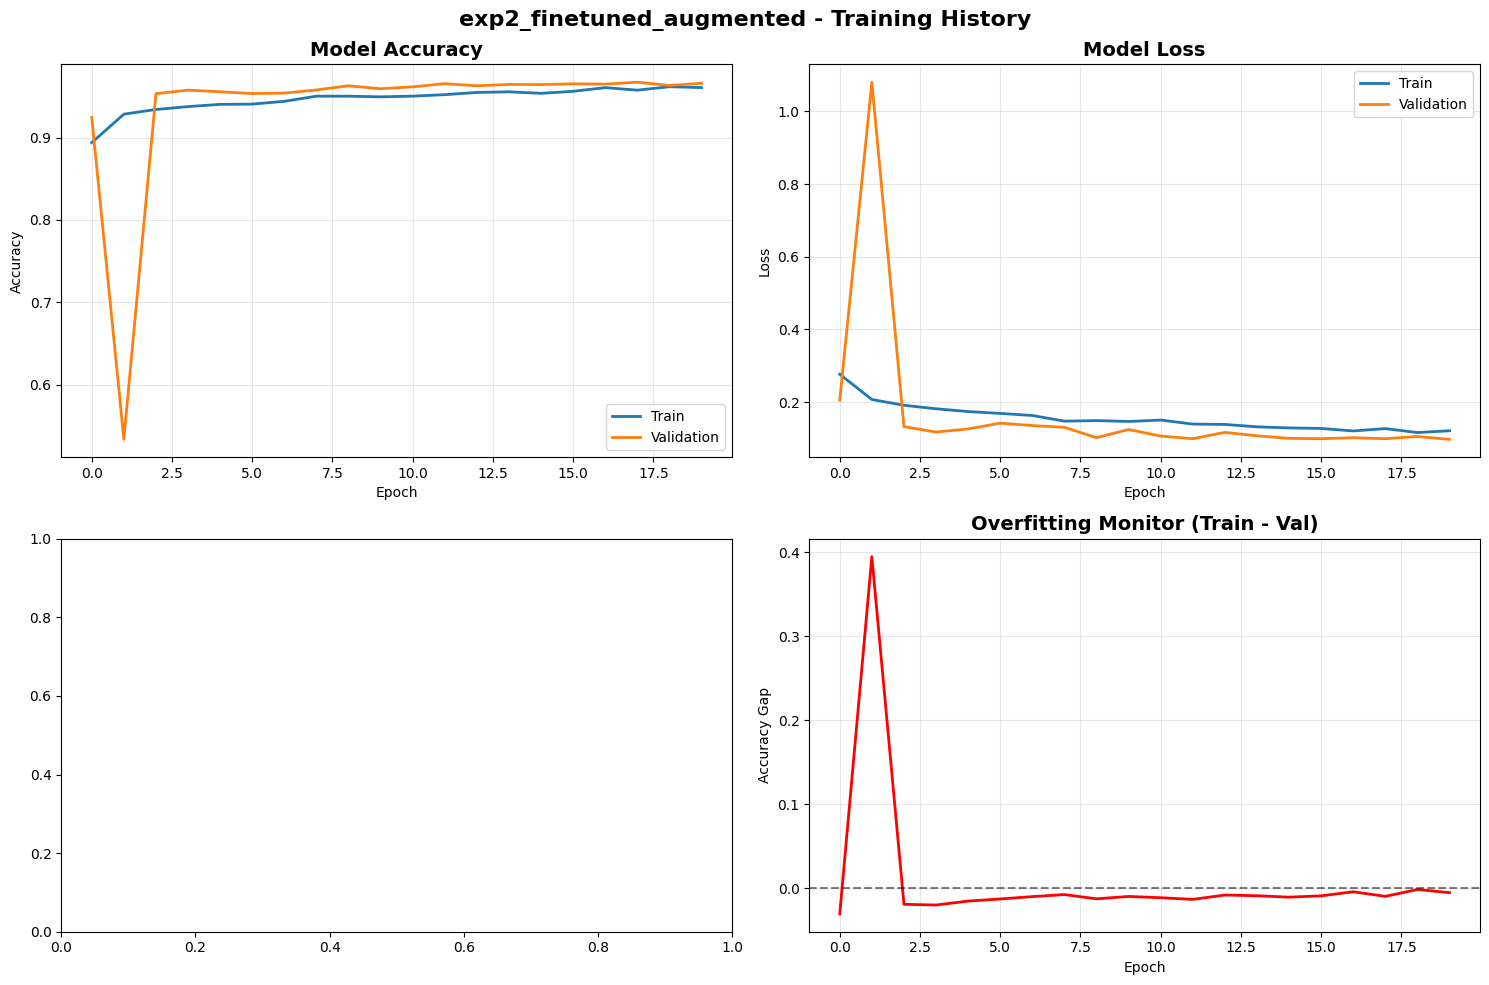

✓ Saved training history plot to vgg16_results/plots/exp2_finetuned_augmented_history.png

EVALUATING: exp2_finetuned_augmented
173/173 ━━━━━━━━━━━━━━━━━━━━ 31s 173ms/step

📊 Test Set Performance:
   Accuracy:  0.9679 (96.79%)
   Precision: 0.9633
   Recall:    0.9728
   F1-Score:  0.9680
   AUC:       0.9944

📋 Classification Report:
              precision    recall  f1-score   support

  Uninfected     0.9725    0.9630    0.9677      2756
 Parasitized     0.9633    0.9728    0.9680      2756

    accuracy                         0.9679      5512
   macro avg     0.9679    0.9679    0.9679      5512
weighted avg     0.9679    0.9679    0.9679      5512


📊 Confusion Matrix:
   TN: 2654  FP:  102
   FN:   75  TP: 2681


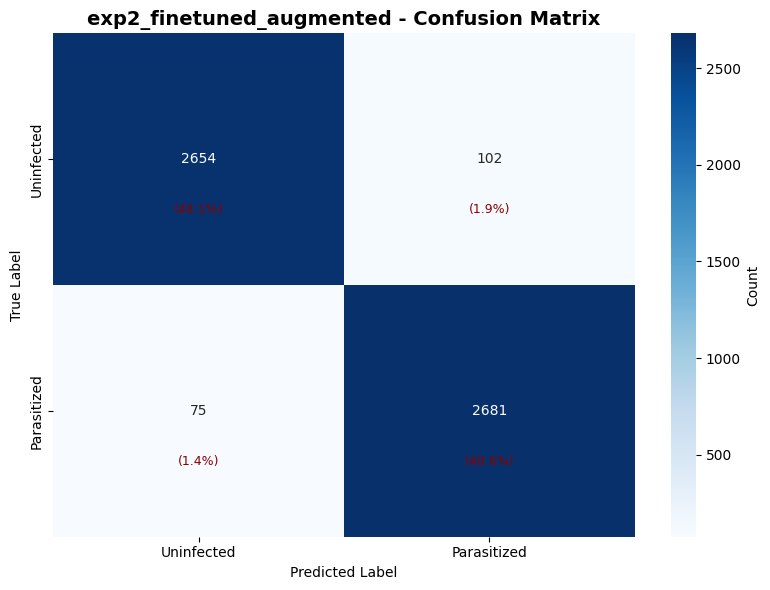

✓ Saved confusion matrix to vgg16_results/plots/exp2_finetuned_augmented_confusion.png


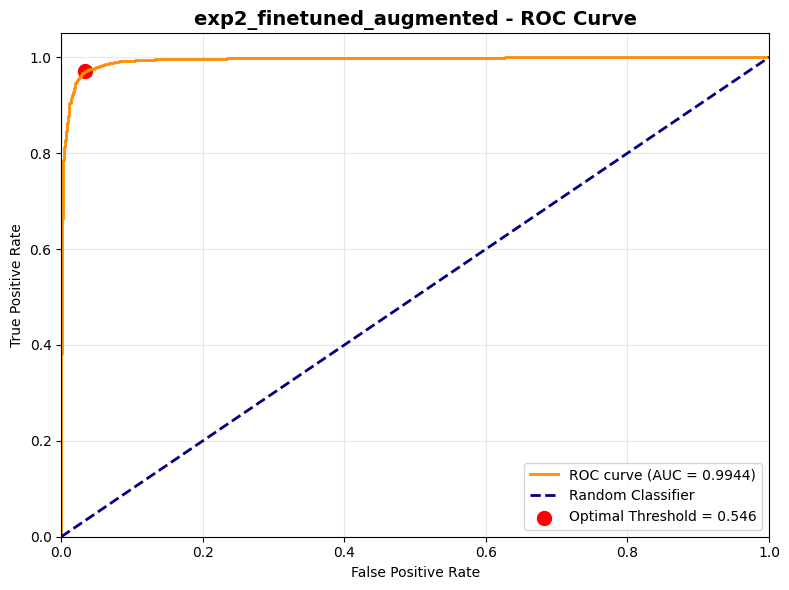

✓ Saved ROC curve to vgg16_results/plots/exp2_finetuned_augmented_roc.png
✓ Saved final model to vgg16_results/checkpoints/exp2_finetuned_augmented_final.h5

EXPERIMENT COMPARISON

📊 Performance Comparison:
              experiment accuracy precision recall f1_score    auc
    exp1_baseline_frozen   0.9528    0.9502 0.9557   0.9530 0.9892
exp2_finetuned_augmented   0.9679    0.9633 0.9728   0.9680 0.9944

📈 Improvements from Baseline to Fine-tuned:
   Accuracy:  +1.51%
   F1-Score:  +1.51%

✓ Saved comparison to vgg16_results/experiment_comparison.csv

✅ EXPERIMENTS COMPLETED SUCCESSFULLY

📋 Summary:
   Baseline Accuracy: 0.9528
   Fine-tuned Accuracy: 0.9679
   Best F1-Score: 0.9680

📁 All results saved in: vgg16_results/
   - Models: checkpoints/
   - Plots: plots/
   - Metrics: *.json files
   - History: *.pkl files


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                        ReduceLROnPlateau, CSVLogger, TensorBoard)
from sklearn.metrics import (classification_report, confusion_matrix,
                            roc_curve, auc, precision_recall_fscore_support)
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*80)
print("VGG16 TRANSFER LEARNING - BEST PRACTICES IMPLEMENTATION")
print("="*80)
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# ==========================================
# SECTION 1: CONFIGURATION (BEST PRACTICES)
# ==========================================

class VGG16Config:
    """Configuration following VGG16 best practices"""

    # Data parameters - VGG16 STANDARD
    DATA_DIR = '/content/cell_images'
    IMG_HEIGHT = 224  # VGG16 was designed for 224x224
    IMG_WIDTH = 224   # Original paper specification
    CHANNELS = 3

    # Data splits - PROPER 60/20/20 split
    TRAIN_SPLIT = 0.6
    VAL_SPLIT = 0.2
    TEST_SPLIT = 0.2

    # Training parameters
    BATCH_SIZE = 32  # Standard for VGG16
    EPOCHS = 20  # Sufficient for convergence
    INITIAL_LR_FROZEN = 1e-3  # Higher for frozen features
    INITIAL_LR_FINETUNE = 1e-4  # Lower for fine-tuning

    # VGG16 specific parameters
    FREEZE_UNTIL = 'block5_conv1'  # Freeze up to block 4
    DROPOUT_RATE = 0.5  # Standard dropout
    DENSE_UNITS = [256, 128]  # Two dense layers for better adaptation

    # Output directories
    OUTPUT_DIR = 'vgg16_results'
    CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints')
    LOG_DIR = os.path.join(OUTPUT_DIR, 'logs')
    PLOT_DIR = os.path.join(OUTPUT_DIR, 'plots')

    @classmethod
    def create_directories(cls):
        """Create necessary directories"""
        for directory in [cls.OUTPUT_DIR, cls.CHECKPOINT_DIR,
                         cls.LOG_DIR, cls.PLOT_DIR]:
            os.makedirs(directory, exist_ok=True)
        print(f"✓ Created output directories in {cls.OUTPUT_DIR}")

# Initialize configuration
config = VGG16Config()
config.create_directories()

# ==========================================
# SECTION 2: DATA PREPARATION WITH PROPER SPLITS
# ==========================================

def prepare_data_with_proper_splits(config):
    """
    Prepare data with proper train/val/test splits
    Following ML best practices for unbiased evaluation
    """

    print("\n" + "="*60)
    print("DATA PREPARATION WITH 60/20/20 SPLIT")
    print("="*60)

    # Count total images
    import glob
    parasitized_images = glob.glob(os.path.join(config.DATA_DIR, 'Parasitized', '*.png'))
    uninfected_images = glob.glob(os.path.join(config.DATA_DIR, 'Uninfected', '*.png'))

    print(f"Found {len(parasitized_images)} parasitized images")
    print(f"Found {len(uninfected_images)} uninfected images")
    print(f"Total: {len(parasitized_images) + len(uninfected_images)} images")

    # Create temporary split directories
    import shutil
    from sklearn.model_selection import train_test_split

    # Clean and create split directories
    split_dir = os.path.join(config.OUTPUT_DIR, 'data_splits')
    if os.path.exists(split_dir):
        shutil.rmtree(split_dir)

    for split in ['train', 'val', 'test']:
        for class_name in ['Parasitized', 'Uninfected']:
            os.makedirs(os.path.join(split_dir, split, class_name), exist_ok=True)

    # Split and copy files
    for class_name, images in [('Parasitized', parasitized_images),
                               ('Uninfected', uninfected_images)]:
        # First split: train+val (80%) vs test (20%)
        train_val_imgs, test_imgs = train_test_split(
            images, test_size=config.TEST_SPLIT, random_state=42
        )

        # Second split: train (60%) vs val (20%)
        # 0.25 of 80% = 20% of total
        train_imgs, val_imgs = train_test_split(
            train_val_imgs, test_size=0.25, random_state=42
        )

        # Copy files to respective directories
        for img_path in train_imgs:
            shutil.copy2(img_path, os.path.join(split_dir, 'train', class_name))
        for img_path in val_imgs:
            shutil.copy2(img_path, os.path.join(split_dir, 'val', class_name))
        for img_path in test_imgs:
            shutil.copy2(img_path, os.path.join(split_dir, 'test', class_name))

    # Verify splits
    for split in ['train', 'val', 'test']:
        para_count = len(os.listdir(os.path.join(split_dir, split, 'Parasitized')))
        uninf_count = len(os.listdir(os.path.join(split_dir, split, 'Uninfected')))
        total = para_count + uninf_count
        print(f"{split.upper():5} set: {total:5} images ({para_count} P, {uninf_count} U)")

    return split_dir

def create_data_generators(split_dir, config, augmentation_for_train=True):
    """
    Create data generators with VGG16 preprocessing
    """

    print("\n=== Creating Data Generators ===")

    # VGG16 preprocessing function
    from tensorflow.keras.applications.vgg16 import preprocess_input

    if augmentation_for_train:
        # Training data generator with augmentation
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,  # VGG16 specific preprocessing
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            vertical_flip=True,
            zoom_range=0.2,
            shear_range=0.1,
            fill_mode='reflect'
        )
        print("✓ Training data augmentation enabled")
    else:
        # Without augmentation
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input
        )
        print("✓ Training without augmentation")

    # Validation and test generators (no augmentation)
    val_test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    # Create generators
    train_generator = train_datagen.flow_from_directory(
        os.path.join(split_dir, 'train'),
        target_size=(config.IMG_HEIGHT, config.IMG_WIDTH),
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        shuffle=True,
        seed=42
    )

    val_generator = val_test_datagen.flow_from_directory(
        os.path.join(split_dir, 'val'),
        target_size=(config.IMG_HEIGHT, config.IMG_WIDTH),
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        shuffle=False,
        seed=42
    )

    test_generator = val_test_datagen.flow_from_directory(
        os.path.join(split_dir, 'test'),
        target_size=(config.IMG_HEIGHT, config.IMG_WIDTH),
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        shuffle=False,
        seed=42
    )

    return train_generator, val_generator, test_generator

# ==========================================
# SECTION 3: VGG16 MODEL ARCHITECTURE
# ==========================================

def build_vgg16_model(config, fine_tuning=False):
    """
    Build VGG16 model following best practices

    Args:
        config: Configuration object
        fine_tuning: If True, unfreeze some layers for fine-tuning
    """

    print("\n=== Building VGG16 Model ===")

    # Clear any existing models
    keras.backend.clear_session()

    # Load pre-trained VGG16
    base_model = VGG16(
        input_shape=(config.IMG_HEIGHT, config.IMG_WIDTH, config.CHANNELS),
        include_top=False,  # Exclude ImageNet classifier
        weights='imagenet'
    )

    print(f"✓ Loaded VGG16 with {len(base_model.layers)} layers")

    # Freeze base model initially
    base_model.trainable = False

    # Build the model
    inputs = keras.Input(shape=(config.IMG_HEIGHT, config.IMG_WIDTH, config.CHANNELS))

    # Pass through VGG16 base
    x = base_model(inputs, training=False)

    # Add custom classifier head
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)

    # First dense block
    x = layers.Dense(config.DENSE_UNITS[0], activation='relu', name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(config.DROPOUT_RATE, name='dropout_1')(x)

    # Second dense block
    x = layers.Dense(config.DENSE_UNITS[1], activation='relu', name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(config.DROPOUT_RATE/2, name='dropout_2')(x)

    # Output layer
    outputs = layers.Dense(1, activation='sigmoid', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='VGG16_Transfer')

    # Fine-tuning configuration
    if fine_tuning:
        base_model.trainable = True

        # Find the layer to freeze until
        freeze_until_layer = None
        for layer in base_model.layers:
            if layer.name == config.FREEZE_UNTIL:
                freeze_until_layer = base_model.layers.index(layer)
                break

        # Freeze layers
        for layer in base_model.layers[:freeze_until_layer]:
            layer.trainable = False

        # Count trainable layers
        trainable_layers = sum([1 for layer in base_model.layers if layer.trainable])
        print(f"✓ Fine-tuning enabled: {trainable_layers} VGG16 layers trainable")

    # Print model summary
    print("\nModel Summary:")
    print(f"Total parameters: {model.count_params():,}")
    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_params:,}")
    non_trainable_params = model.count_params() - trainable_params
    print(f"Non-trainable parameters: {non_trainable_params:,}")

    return model, base_model

# ==========================================
# SECTION 4: TRAINING UTILITIES
# ==========================================

def get_callbacks(experiment_name, config):
    """
    Create comprehensive callbacks for training
    """

    callbacks = []

    # Model checkpoint
    checkpoint_path = os.path.join(
        config.CHECKPOINT_DIR,
        f'{experiment_name}_best.h5'
    )
    checkpoint = ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',  # Monitor validation accuracy
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1
    )
    callbacks.append(checkpoint)

    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=7,  # More patience for better convergence
        restore_best_weights=True,
        verbose=1
    )
    callbacks.append(early_stop)

    # Learning rate reduction
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
    callbacks.append(reduce_lr)

    # CSV logger
    csv_path = os.path.join(config.LOG_DIR, f'{experiment_name}_history.csv')
    csv_logger = CSVLogger(csv_path, separator=',', append=False)
    callbacks.append(csv_logger)

    # TensorBoard
    tb_path = os.path.join(config.LOG_DIR, 'tensorboard', experiment_name)
    tensorboard = TensorBoard(log_dir=tb_path, histogram_freq=0)
    callbacks.append(tensorboard)

    return callbacks

# ==========================================
# SECTION 5: EVALUATION FUNCTIONS
# ==========================================

def evaluate_model(model, test_generator, experiment_name, config):
    """
    Comprehensive model evaluation on test set
    """

    print("\n" + "="*60)
    print(f"EVALUATING: {experiment_name}")
    print("="*60)

    # Get predictions
    test_generator.reset()
    predictions = model.predict(test_generator, verbose=1)
    y_pred_probs = predictions.flatten()
    y_pred = (y_pred_probs > 0.5).astype(int)
    y_true = test_generator.classes

    # Calculate metrics
    accuracy = np.mean(y_pred == y_true)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    # Calculate AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    # Print metrics
    print("\n📊 Test Set Performance:")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   AUC:       {roc_auc:.4f}")

    # Classification report
    print("\n📋 Classification Report:")
    print(classification_report(y_true, y_pred,
                              target_names=['Uninfected', 'Parasitized'],
                              digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\n📊 Confusion Matrix:")
    print(f"   TN: {cm[0,0]:4d}  FP: {cm[0,1]:4d}")
    print(f"   FN: {cm[1,0]:4d}  TP: {cm[1,1]:4d}")

    # Save metrics
    metrics = {
        'experiment': experiment_name,
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'auc': float(roc_auc),
        'confusion_matrix': cm.tolist()
    }

    metrics_path = os.path.join(config.OUTPUT_DIR, f'{experiment_name}_metrics.json')
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=2)

    return metrics, y_true, y_pred, y_pred_probs

def plot_training_history(history, experiment_name, config):
    """
    Plot comprehensive training history
    """

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Learning rate
    if 'lr' in history.history:
        axes[1, 0].plot(history.history['lr'], linewidth=2, color='green')
        axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Learning Rate')
        axes[1, 0].set_yscale('log')
        axes[1, 0].grid(True, alpha=0.3)

    # Train-Val Gap
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    gap = [t - v for t, v in zip(train_acc, val_acc)]
    axes[1, 1].plot(gap, linewidth=2, color='red')
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1, 1].set_title('Overfitting Monitor (Train - Val)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy Gap')
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f'{experiment_name} - Training History', fontsize=16, fontweight='bold')
    plt.tight_layout()

    # Save
    plot_path = os.path.join(config.PLOT_DIR, f'{experiment_name}_history.png')
    plt.savefig(plot_path, dpi=100, bbox_inches='tight')
    plt.show()

    print(f"✓ Saved training history plot to {plot_path}")

def plot_confusion_matrix(y_true, y_pred, experiment_name, config):
    """
    Plot confusion matrix
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Uninfected', 'Parasitized'],
                yticklabels=['Uninfected', 'Parasitized'],
                cbar_kws={'label': 'Count'})

    # Add percentages
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            percentage = 100 * cm[i, j] / total
            plt.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                    ha='center', va='center', fontsize=9, color='darkred')

    plt.title(f'{experiment_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    # Save
    plot_path = os.path.join(config.PLOT_DIR, f'{experiment_name}_confusion.png')
    plt.savefig(plot_path, dpi=100, bbox_inches='tight')
    plt.show()

    print(f"✓ Saved confusion matrix to {plot_path}")

def plot_roc_curve(y_true, y_scores, experiment_name, config):
    """
    Plot ROC curve with AUC
    """

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random Classifier')

    # Find optimal threshold
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100,
                label=f'Optimal Threshold = {optimal_threshold:.3f}')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{experiment_name} - ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save
    plot_path = os.path.join(config.PLOT_DIR, f'{experiment_name}_roc.png')
    plt.savefig(plot_path, dpi=100, bbox_inches='tight')
    plt.show()

    print(f"✓ Saved ROC curve to {plot_path}")

# ==========================================
# SECTION 6: MAIN EXPERIMENTS
# ==========================================

def experiment_1_baseline(config, split_dir):
    """
    Experiment 1: Baseline with frozen VGG16 features
    """

    print("\n" + "="*80)
    print("EXPERIMENT 1: BASELINE VGG16 (FROZEN FEATURES)")
    print("="*80)

    experiment_name = "exp1_baseline_frozen"

    # Create data generators WITHOUT augmentation for baseline
    train_gen, val_gen, test_gen = create_data_generators(
        split_dir, config, augmentation_for_train=False
    )

    # Build model with frozen features
    model, base_model = build_vgg16_model(config, fine_tuning=False)

    # Compile with higher learning rate for frozen features
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.INITIAL_LR_FROZEN),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )

    # Get callbacks
    callbacks = get_callbacks(experiment_name, config)

    # Train
    print("\n📊 Training Baseline Model...")
    print("-" * 40)

    history = model.fit(
        train_gen,
        epochs=config.EPOCHS,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1
    )

    # Plot training history
    plot_training_history(history, experiment_name, config)

    # Evaluate on test set
    metrics, y_true, y_pred, y_scores = evaluate_model(
        model, test_gen, experiment_name, config
    )

    # Plot confusion matrix and ROC
    plot_confusion_matrix(y_true, y_pred, experiment_name, config)
    plot_roc_curve(y_true, y_scores, experiment_name, config)

    # Save model
    model_path = os.path.join(config.CHECKPOINT_DIR, f'{experiment_name}_final.h5')
    model.save(model_path)
    print(f"✓ Saved final model to {model_path}")

    # Save history
    history_path = os.path.join(config.OUTPUT_DIR, f'{experiment_name}_history.pkl')
    with open(history_path, 'wb') as f:
        pickle.dump(history.history, f)

    return metrics, history

def experiment_2_finetuned(config, split_dir):
    """
    Experiment 2: Fine-tuned VGG16 with data augmentation
    """

    print("\n" + "="*80)
    print("EXPERIMENT 2: FINE-TUNED VGG16 WITH AUGMENTATION")
    print("="*80)

    experiment_name = "exp2_finetuned_augmented"

    # Create data generators WITH augmentation
    train_gen, val_gen, test_gen = create_data_generators(
        split_dir, config, augmentation_for_train=True
    )

    # Build model with fine-tuning
    model, base_model = build_vgg16_model(config, fine_tuning=True)

    # Compile with lower learning rate for fine-tuning
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.INITIAL_LR_FINETUNE),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )

    # Get callbacks
    callbacks = get_callbacks(experiment_name, config)

    # Train
    print("\n📊 Training Fine-tuned Model...")
    print("-" * 40)

    history = model.fit(
        train_gen,
        epochs=config.EPOCHS,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1
    )

    # Plot training history
    plot_training_history(history, experiment_name, config)

    # Evaluate on test set
    metrics, y_true, y_pred, y_scores = evaluate_model(
        model, test_gen, experiment_name, config
    )

    # Plot confusion matrix and ROC
    plot_confusion_matrix(y_true, y_pred, experiment_name, config)
    plot_roc_curve(y_true, y_scores, experiment_name, config)

    # Save model
    model_path = os.path.join(config.CHECKPOINT_DIR, f'{experiment_name}_final.h5')
    model.save(model_path)
    print(f"✓ Saved final model to {model_path}")

    # Save history
    history_path = os.path.join(config.OUTPUT_DIR, f'{experiment_name}_history.pkl')
    with open(history_path, 'wb') as f:
        pickle.dump(history.history, f)

    return metrics, history

# ==========================================
# SECTION 7: COMPARISON AND ANALYSIS
# ==========================================

def compare_experiments(exp1_metrics, exp2_metrics, config):
    """
    Create comparison table and analysis
    """

    print("\n" + "="*80)
    print("EXPERIMENT COMPARISON")
    print("="*80)

    # Create comparison DataFrame
    comparison = pd.DataFrame([exp1_metrics, exp2_metrics])
    comparison = comparison[['experiment', 'accuracy', 'precision', 'recall', 'f1_score', 'auc']]

    # Format for display
    for col in ['accuracy', 'precision', 'recall', 'f1_score', 'auc']:
        comparison[col] = comparison[col].apply(lambda x: f"{x:.4f}")

    print("\n📊 Performance Comparison:")
    print(comparison.to_string(index=False))

    # Calculate improvements
    acc_improvement = (float(exp2_metrics['accuracy']) - float(exp1_metrics['accuracy'])) * 100
    f1_improvement = (float(exp2_metrics['f1_score']) - float(exp1_metrics['f1_score'])) * 100

    print(f"\n📈 Improvements from Baseline to Fine-tuned:")
    print(f"   Accuracy:  +{acc_improvement:.2f}%")
    print(f"   F1-Score:  +{f1_improvement:.2f}%")

    # Save comparison
    comparison_path = os.path.join(config.OUTPUT_DIR, 'experiment_comparison.csv')
    comparison.to_csv(comparison_path, index=False)
    print(f"\n✓ Saved comparison to {comparison_path}")

    return comparison

# ==========================================
# SECTION 8: MAIN EXECUTION
# ==========================================

print("\n" + "="*80)
print("🚀 STARTING VGG16 EXPERIMENTS")
print("="*80)

# Prepare data splits
split_dir = prepare_data_with_proper_splits(config)

# Run Experiment 1: Baseline
print("\n" + "="*80)
print("📊 PHASE 1: BASELINE EXPERIMENT")
print("="*80)
exp1_metrics, exp1_history = experiment_1_baseline(config, split_dir)

# Run Experiment 2: Fine-tuned
print("\n" + "="*80)
print("📊 PHASE 2: FINE-TUNING EXPERIMENT")
print("="*80)
exp2_metrics, exp2_history = experiment_2_finetuned(config, split_dir)

# Compare results
comparison = compare_experiments(exp1_metrics, exp2_metrics, config)

# Final summary
print("\n" + "="*80)
print("✅ EXPERIMENTS COMPLETED SUCCESSFULLY")
print("="*80)

print("\n📋 Summary:")
print(f"   Baseline Accuracy: {exp1_metrics['accuracy']:.4f}")
print(f"   Fine-tuned Accuracy: {exp2_metrics['accuracy']:.4f}")
print(f"   Best F1-Score: {max(exp1_metrics['f1_score'], exp2_metrics['f1_score']):.4f}")

print(f"\n📁 All results saved in: {config.OUTPUT_DIR}/")
print("   - Models: checkpoints/")
print("   - Plots: plots/")
print("   - Metrics: *.json files")
print("   - History: *.pkl files")